<a href="https://colab.research.google.com/github/Malak23272/MachineLearningProject/blob/main/defualtcreditcard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
#Data Acquisition and Retrieval
df=pd.read_csv("default of credit card clients.csv",header=1)

#check nulls
df.info()
# Returns the sum of technical null values for every column
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [5]:
#check duplicates to avoid unreliable dataset
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()  #check mean ,avg,std

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


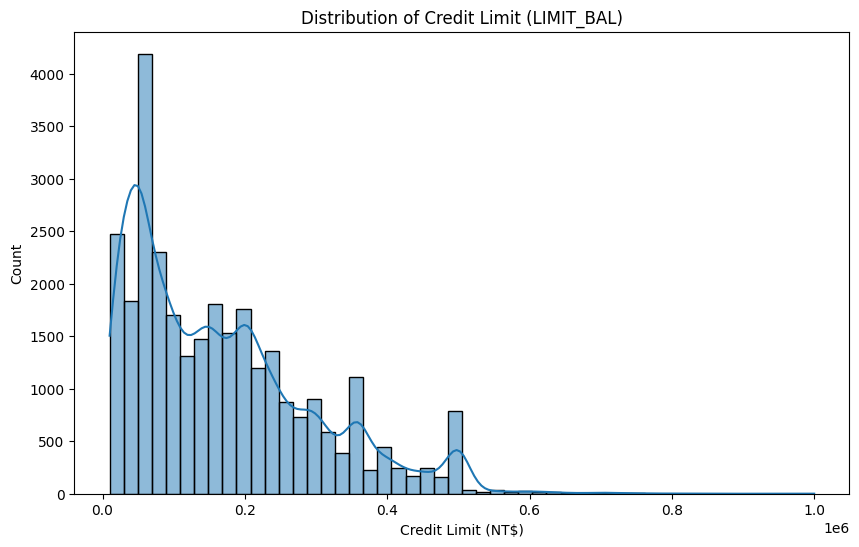

Original Skew: 0.9928669605195444
CAPPED Skew: 0.8900648069212629
Transformed(logged) Skew: -0.5237778599522682
SQRT Skew: 0.27665537987394345


In [7]:
#Visualization For Outliers Checkness
plt.figure(figsize=(10, 6))
sns.histplot(df['LIMIT_BAL'], kde=True, bins=50)
plt.title('Distribution of Credit Limit (LIMIT_BAL)')
plt.xlabel('Credit Limit (NT$)')
plt.ylabel('Count')
plt.show()

#Since It's Left Skewed
#Outliers Solution by:
# 1. Define the 99th percentile threshold
upper_limit = df['LIMIT_BAL'].quantile(0.99)

# 2. Cap the values
df['LIMIT_BAL_CAPPED'] = df['LIMIT_BAL'].clip(upper=upper_limit)

# Apply Log Transformation to the capped column bec of zeros
df['LIMIT_BAL_LOG'] = np.log1p(df['LIMIT_BAL_CAPPED'])

#Verifying:
# Check the skewness: closer to 0 is better (more "Normal") #Means that Mean and Median are close to each other
print(f"Original Skew: {df['LIMIT_BAL'].skew()}")
print(f"CAPPED Skew: {df['LIMIT_BAL_CAPPED'].skew()}")
print(f"Transformed(logged) Skew: {df['LIMIT_BAL_LOG'].skew()}")

# Square root is gentler than Log
df['LIMIT_BAL_SQRT'] = np.sqrt(df['LIMIT_BAL'])
print(f"SQRT Skew: {df['LIMIT_BAL_SQRT'].skew()}") #much better "centered better"

In [8]:
# Check skewness for all payment columns
pay_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
print(df[pay_cols].skew())
pay_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Calculate Skewness for both methods
log_skew = np.log1p(df[pay_cols]).skew() #better for outliers
sqrt_skew = np.sqrt(df[pay_cols]).skew()

print("Log1p Skewness:\n", log_skew)
print("\nSquare Root Skewness:\n", sqrt_skew)

PAY_AMT1    14.668364
PAY_AMT2    30.453817
PAY_AMT3    17.216635
PAY_AMT4    12.904985
PAY_AMT5    11.127417
PAY_AMT6    10.640727
dtype: float64
Log1p Skewness:
 PAY_AMT1   -1.292375
PAY_AMT2   -1.239832
PAY_AMT3   -1.079249
PAY_AMT4   -0.966038
PAY_AMT5   -0.938329
PAY_AMT6   -0.854558
dtype: float64

Square Root Skewness:
 PAY_AMT1    3.075763
PAY_AMT2    4.028331
PAY_AMT3    3.400755
PAY_AMT4    3.207401
PAY_AMT5    3.148955
PAY_AMT6    3.375951
dtype: float64


In [9]:
# Grouping unknown values into the 'Others' category (4 for Education, 3 for Marriage)
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df['SEX'].value_counts() #all valid

SEX
2    18112
1    11888
Name: count, dtype: int64

In [10]:
#since we have outliers categorical and numerical
#categorical marriage and education
# Keep only rows where EDUCATION is between 1 and 4
df = df[(df['EDUCATION'] >= 1) & (df['EDUCATION'] <= 4)]

# Keep only rows where MARRIAGE is 1, 2, or 3
df = df[df['MARRIAGE'].isin([1, 2, 3])]

In [11]:
df['default payment next month'].value_counts() #to know number of defaults and number of non determine imbalance

default payment next month
0    23364
1     6636
Name: count, dtype: int64

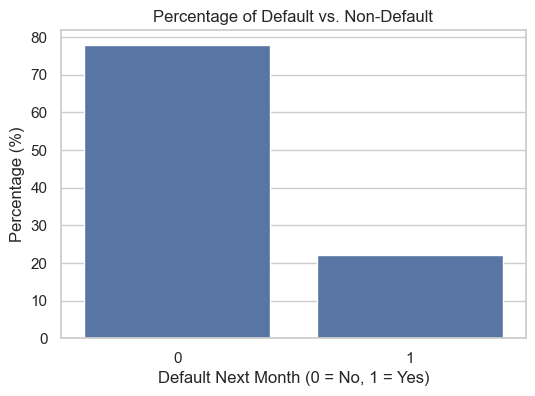

In [12]:
# Set a nice style for the plots
sns.set_theme(style="whitegrid")

# Calculate percentages
# normalize=True gives fractions (e.g., 0.78 and 0.22). Multiplying by 100 gives percentages.
percent_data = df['default payment next month'].value_counts(normalize=True) * 100

# Create a bar plot using the calculated percentages
plt.figure(figsize=(6, 4))
sns.barplot(x=percent_data.index, y=percent_data.values)

plt.title('Percentage of Default vs. Non-Default')
plt.xlabel('Default Next Month (0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')
plt.show()

In [13]:
# 1. Extract the Target (y) - Just the one column we want to predict
y = df['default payment next month']

# 2. Extract the Features (X) - Drop the target and the ID column
X = df.drop(columns=['default payment next month', 'ID'])

# 3. Quick verification to ensure the shapes make sense
print("Shape of X (Features):", X.shape)
print("Shape of y (Target):", y.shape)

Shape of X (Features): (30000, 26)
Shape of y (Target): (30000,)


In [14]:
# 1. Identify your categorical columns that have no mathematical order
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

# 2. Apply One-Hot Encoding (get_dummies)
# drop_first=True prevents the "Dummy Variable Trap" (perfect collinearity)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Check your new columns!
print("Original number of columns:", X.shape[1])
print("New number of columns:", X_encoded.shape[1])
print(X_encoded.columns)

Original number of columns: 26
New number of columns: 29
Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'LIMIT_BAL_CAPPED', 'LIMIT_BAL_LOG',
       'LIMIT_BAL_SQRT', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4',
       'MARRIAGE_2', 'MARRIAGE_3'],
      dtype='str')


In [15]:
# STEP 1: SPLIT
# We lock away 20% of the data into the X_test vault immediately.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# STEP 2: SCALE (Standardization)
# We calculate the math using ONLY X_train, then apply it to both.
scaler = StandardScaler()

# fit_transform does both steps at once for the training data
X_train_scaled = scaler.fit_transform(X_train) 

# transform ONLY applies the math to the test data (no peeking!)
X_test_scaled = scaler.transform(X_test)

In [17]:
# STEP 3: SMOTE (Handling Imbalance)
# We generate fake defaults ONLY inside the training environment.
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [18]:
print(f"Original Training Imbalance:\n{y_train.value_counts()}\n")
print(f"New SMOTE Training Balance:\n{pd.Series(y_train_balanced).value_counts()}")

Original Training Imbalance:
default payment next month
0    18691
1     5309
Name: count, dtype: int64

New SMOTE Training Balance:
default payment next month
0    18691
1    18691
Name: count, dtype: int64


C:\Users\MALAK\AppData\Local\Temp\ipykernel_19444\4157780472.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette="Reds")
C:\Users\MALAK\AppData\Local\Temp\ipykernel_19444\4157780472.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_balanced_series, ax=axes[1], palette="Greens")


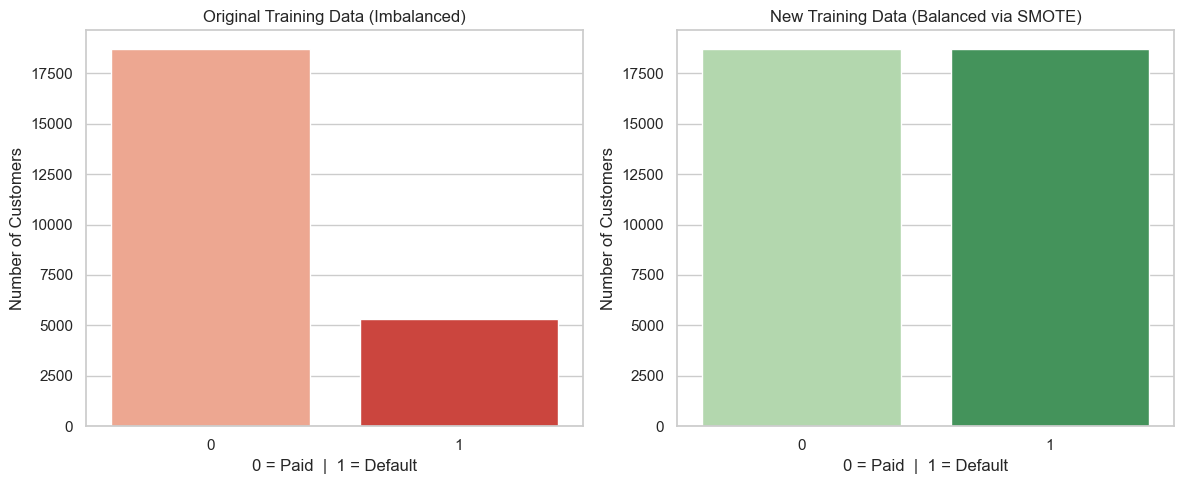

In [19]:
y_train_balanced_series = pd.Series(y_train_balanced)

# Set up the matplotlib figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- PLOT 1: Before SMOTE ---
sns.countplot(x=y_train, ax=axes[0], palette="Reds")
axes[0].set_title("Original Training Data (Imbalanced)")
axes[0].set_xlabel("0 = Paid  |  1 = Default")
axes[0].set_ylabel("Number of Customers")

# --- PLOT 2: After SMOTE ---
sns.countplot(x=y_train_balanced_series, ax=axes[1], palette="Greens")
axes[1].set_title("New Training Data (Balanced via SMOTE)")
axes[1].set_xlabel("0 = Paid  |  1 = Default")
axes[1].set_ylabel("Number of Customers")

# Adjust layout so they don't overlap and display the plot
plt.tight_layout()
plt.show()

In [35]:

# random_state ensures reproducibility. 
# n_estimators=100 builds a forest of 100 individual trees.
model_dt = DecisionTreeClassifier(random_state=42)

# RUN THE TEST FOR DECISION TREE
scores_dt = cross_val_score(model_dt, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')


#  THE FINAL LEADERBOARD
print(f"Scores across 5 tests: {scores_dt}")
print(f"Decision Tree Average:         {np.mean(scores_dt):.4f}")

Scores across 5 tests: [0.68142303 0.75324328 0.81153023 0.81447298 0.81153023]
Decision Tree Average:         0.7744


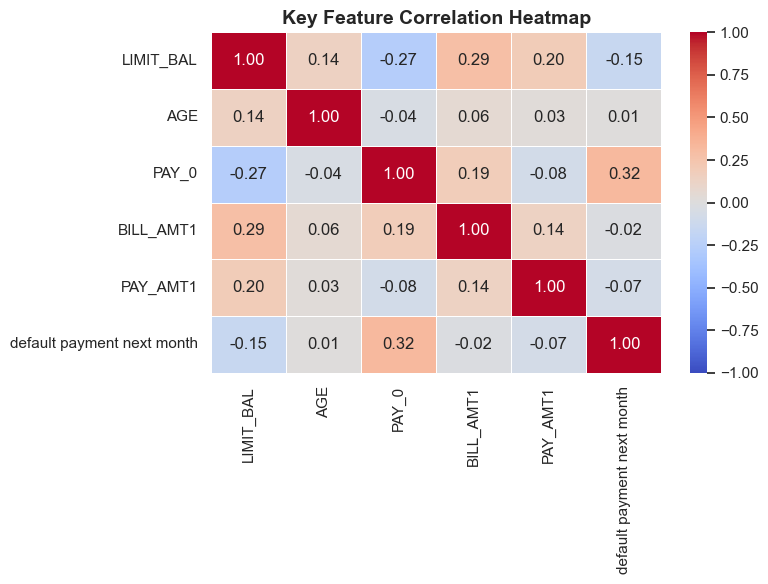

In [28]:

# Set the visual style for professional reporting
sns.set_theme(style="whitegrid")

# We only select a subset of features to keep the heatmap readable
subset_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'default payment next month']
corr_matrix = df[subset_cols].corr()

# Set up a single matplotlib figure
plt.figure(figsize=(8, 6))

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# Add a professional title
plt.title("Key Feature Correlation Heatmap", fontsize=14, fontweight='bold')

# Display the plot cleanly
plt.tight_layout()
plt.show()

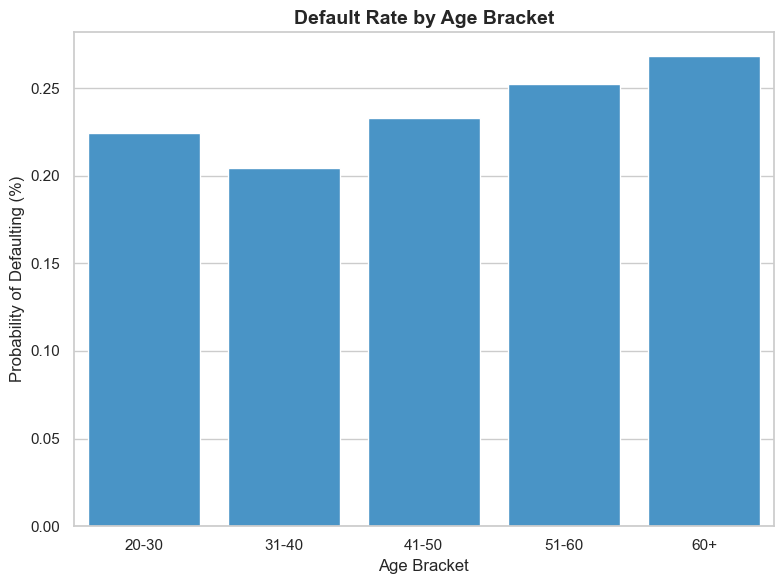

In [32]:
# Set the professional visual style
sns.set_theme(style="whitegrid")

# 1. Group the ages into clean brackets so the chart is readable
df['AGE_BIN'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80], labels=['20-30', '31-40', '41-50', '51-60', '60+'])

# 2. Set up a single, cleanly sized canvas
plt.figure(figsize=(8, 6))

# 3. Plot the bar chart (errorbar=None removes the confusing black error lines)
sns.barplot(data=df, x='AGE_BIN', y='default payment next month', color='#3498DB', errorbar=None)

# 4. Add professional titles and labels
plt.title("Default Rate by Age Bracket", fontsize=14, fontweight='bold')
plt.ylabel("Probability of Defaulting (%)")
plt.xlabel("Age Bracket")

# 5. Display the plot cleanly
plt.tight_layout()
plt.show()